In [22]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import numpy.ma as ma
from domain import *
import xarray as xr
from netCDF4 import Dataset
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

# ELEVATION & ICE DATA

In [23]:
#HMA = GRh
dsHMA=xr.open_dataset('/home/santolam/NST.2000.09.01.00.GRh.nc')
dsSH_hma=dsHMA['SH']#[nx:-nx,ny:-ny]
LONS_hma,LATS_hma=dsHMA.LON,dsHMA.LAT

In [24]:
nx=ny=10 # Enlever les bords du domaine pour éviter les problèmes de bord du domaine

#Nepal = GRq
ds_nepal=xr.open_dataset('/home/santolam/NST.2000.01.01.00.GRc.nc')#['SH']#[nx:-nx,ny:-ny]
dsSH_nepal=ds_nepal['SH'][nx:-nx,ny:-ny]
dsICE_nepal=ds_nepal['ICE'][nx:-nx,ny:-ny] # Domaine sous glace selon MAR
LONS_nepal,LATS_nepal=ds_nepal.LON[nx:-nx,ny:-ny],ds_nepal.LAT[nx:-nx,ny:-ny]

#Pamir = GRp
ds_pamir=xr.open_dataset('/home/santolam/NST.2014.01.01.00.GRi.nc')#['SH']#[nx:-nx,ny:-ny]
dsSH_pamir=ds_pamir['SH'][nx:-nx,ny:-ny]
dsICE_pamir=ds_pamir['ICE'][nx:-nx,ny:-ny]
LONS_pamir,LATS_pamir=ds_pamir.LON[nx:-nx,ny:-ny],ds_pamir.LAT[nx:-nx,ny:-ny]

# PLOT

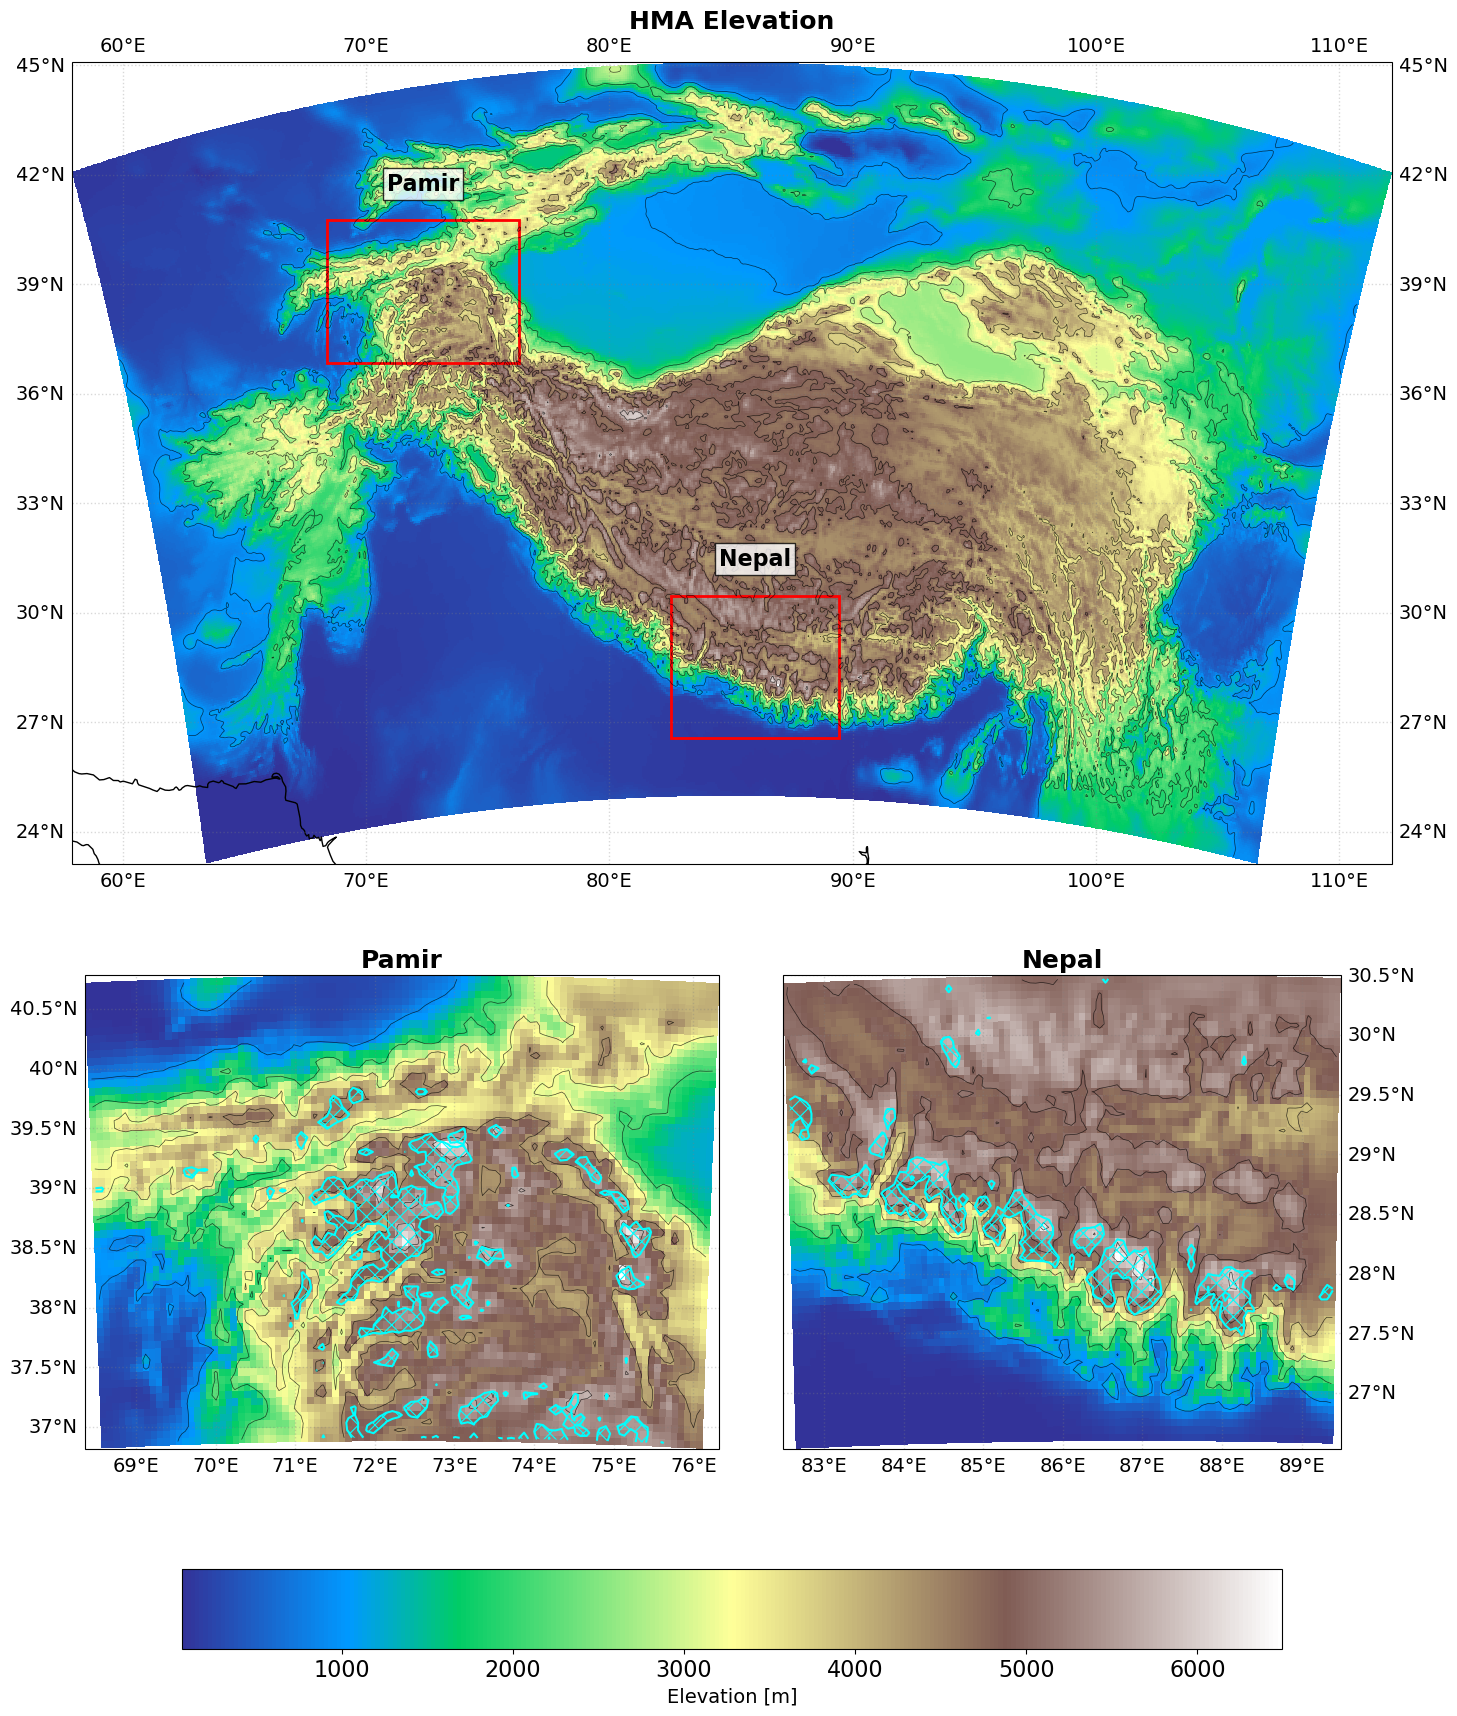

In [25]:
# Pour ICE contour & hachures
import matplotlib as mpl
mpl.rcParams['hatch.color'] = 'cyan'
mpl.rcParams['hatch.linewidth'] = 0.8

cmap='terrain'

# Compute rectangle coordinates automatically for GRq & GRp
nepal_box = [LONS_nepal.min().item(), LONS_nepal.max().item(),
             LATS_nepal.min().item(), LATS_nepal.max().item()]

pamir_box = [LONS_pamir.min().item(), LONS_pamir.max().item(),
             LATS_pamir.min().item(), LATS_pamir.max().item()]

# Create figure and gridspec layout
fig = plt.figure(figsize=(22, 40))
gs = fig.add_gridspec(2, 2, height_ratios=[1.75, 1])

# Row 1: full-width HMA plot
ax0 = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
CS0 = ax0.pcolormesh(LONS_hma, LATS_hma,dsSH_hma,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,shading="auto")
ax0.coastlines()
ax0.set_title('HMA Elevation',fontsize=18,weight="bold")
gl = ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
ax0.set_aspect(1.5)
SH0 = ax0.contour(LONS_hma, LATS_hma, dsSH_hma,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
#ax0.clabel(SH0, inline=True, fontsize=12, fmt="%d")

# Add red rectangles for subdomains
for box in [nepal_box, pamir_box]:
    rect = Rectangle((box[0], box[2]), box[1]-box[0], box[3]-box[2],
                     linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree())
    ax0.add_patch(rect)

name = ['Nepal', 'Pamir']
i=0
for box in [nepal_box, pamir_box]:
    nom = name[i]
    i = i+1
    latS, latN, lonW, lonE = box[2], box[3], box[0], box[1]
    ax0.text((lonW + lonE) / 2, latN + 1, nom,horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
            color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

# Row 2: two half-width subdomain plots
ax1 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
CS1 = ax1.pcolormesh(LONS_pamir, LATS_pamir,dsSH_pamir,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,shading="auto")

ax1.set_title('Pamir',fontsize=18,weight="bold")
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
gl.top_labels = False
gl.right_labels = False
ax1.set_aspect(1.5)
SH1 = ax1.contour(LONS_pamir, LATS_pamir, dsSH_pamir,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())

ICE1 = ax1.contourf(
    LONS_pamir, LATS_pamir, dsICE_pamir,
    levels=[20,100],
    hatches=['XX','XX', 'XX'],     # or ['X','X']
    colors='none',            # no face fill
    transform=ccrs.PlateCarree(),
    zorder=5                  # put hatch on top of pcolormesh
)

ax1.contour(
    LONS_pamir, LATS_pamir, dsICE_pamir,
    levels=[20],              # seuil du contour
    colors='cyan',
    linewidths=1.5,
    transform=ccrs.PlateCarree(),
    zorder=6
)


ax2 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
CS2 = ax2.pcolormesh(LONS_nepal, LATS_nepal,dsSH_nepal,
                   transform=ccrs.PlateCarree(),
                   cmap=cmap ,shading="auto")

ax2.set_title('Nepal',fontsize=18,weight="bold")
gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}
gl.top_labels = False
gl.left_labels = False
ax2.set_aspect(1.5)
SH2 = ax2.contour(LONS_nepal, LATS_nepal, dsSH_nepal,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())

ICE2 = ax2.contourf(
    LONS_nepal, LATS_nepal, dsICE_nepal,
    levels=[20, 100],
    hatches=['XX', 'XX'],     # or ['X','X']
    colors='none',            # no face fill
    transform=ccrs.PlateCarree(),
    zorder=4                  # put hatch on top of pcolormesh
)

ax2.contour(
    LONS_nepal, LATS_nepal, dsICE_nepal,
    levels=[20],
    colors='cyan',
    linewidths=1.5,
    transform=ccrs.PlateCarree(),
    zorder=6
)

cbar_ax = fig.add_axes([0.25, 0.15, 0.5, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(CS2, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'Elevation '}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.55, bottom=0.2, wspace=0.00000001, hspace=0.15)

plt.show()
plt.show()

In [26]:
nepal_box

[82.52400207519531, 89.45405578613281, 26.56639289855957, 30.469270706176758]

In [27]:
pamir_box

[68.39894104003906, 76.28392028808594, 36.85060501098633, 40.75126647949219]

In [28]:
#Nepal = GRq
ds_nepal=xr.open_dataset('/home/santolam/NST.2000.01.01.00.GRc.nc')#['SH']#[nx:-nx,ny:-ny]
LONS_nepal,LATS_nepal=ds_nepal.LON,ds_nepal.LAT

#Pamir = GRp
ds_pamir=xr.open_dataset('/home/santolam/NST.2014.01.01.00.GRi.nc')#['SH']#[nx:-nx,ny:-ny]
LONS_pamir,LATS_pamir=ds_pamir.LON,ds_pamir.LAT

In [29]:
# Compute rectangle coordinates automatically for GRq & GRp
nepal_box = [LONS_nepal.min().item(), LONS_nepal.max().item(),
             LATS_nepal.min().item(), LATS_nepal.max().item()]

pamir_box = [LONS_pamir.min().item(), LONS_pamir.max().item(),
             LATS_pamir.min().item(), LATS_pamir.max().item()]

In [30]:
nepal_box

[81.76435852050781, 90.20372009277344, 25.915502548217773, 31.098318099975586]

In [31]:
pamir_box

[67.52656555175781, 77.15697479248047, 36.194671630859375, 41.38050842285156]